# Fetch planets' positions relative to ESMUC

In [1]:
!pip3 install ephem


[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip



https://rhodesmill.org/pyephem/quick
https://rhodesmill.org/pyephem/radec
https://rhodesmill.org/pyephem/tutorial.html

In [2]:
def pretty(d, indent=0):
   for key, value in d.items():
      print('\t' * indent + str(key))
      if isinstance(value, dict):
         pretty(value, indent+1)
      else:
         print('\t' * (indent+1) + str(value))

## Get data

In [104]:
import ephem

planets = [
    ephem.Moon(),
    ephem.Mercury(),
    ephem.Venus(),
    ephem.Mars(),
    ephem.Jupiter(),
    ephem.Saturn(),
    ephem.Uranus()
]



measurings = dict.fromkeys((planet.name for planet in planets), {}) # Initialize dictionary

# Set up observing point
observer = ephem.Observer()
observer.name = "ESMUC"
observer.lat = '41.39858935189999'
observer.lon = '2.1853450576007365'
observer.elevation = 18  # meters
observer.pressure = 0


startingDate = ephem.Date('2026/06/01 00:00')
observer.date = startingDate - 2 * ephem.hour # ephem works with UTC. This accounts for the timezone

rangDies = 30 # days that the simulation will run
stepHores = 4 # how many hours are stepped
print((24 * rangDies) / (stepHores)) # number of iterations that will run

iterations = 0

while(iterations < (24 * rangDies) / (stepHores)):
    for _, planet in enumerate(planets):
        planet.compute(observer)
        dateValues = dict({
            str(observer.date): {
                'separation': ephem.separation(observer, planet), 
                'mag': planet.mag, 
                'size': planet.size, 
                'alt': planet.alt, 
                'az': planet.az,
                'earth_distance': planet.earth_distance * 1000
                }
            })
            
        measurings[planet.name] =  {**measurings[planet.name], **dateValues}
        
    iterations += 1
    observer.date += stepHores * ephem.hour

print(iterations)
pretty((measurings))


180.0
180
Moon
	2026/5/31 22:00:00
		separation
			120:28:42.2
		mag
			-12.36
		size
			1773.332763671875
		alt
			13:36:45.2
		az
			149:56:30.1
		earth_distance
			2.7057649567723274
	2026/6/1 02:00:00
		separation
			119:29:50.5
		mag
			-12.32
		size
			1774.49853515625
		alt
			16:17:33.1
		az
			202:50:06.5
		earth_distance
			2.703987527638674
	2026/6/1 06:00:00
		separation
			118:06:59.5
		mag
			-12.28
		size
			1760.033935546875
		alt
			-13:52:02.6
		az
			244:09:30.5
		earth_distance
			2.72620958276093
	2026/6/1 10:00:00
		separation
			116:10:53.7
		mag
			-12.23
		size
			1743.922607421875
		alt
			-55:48:52.5
		az
			280:08:57.3
		earth_distance
			2.7513955719769
	2026/6/1 14:00:00
		separation
			114:03:01.0
		mag
			-12.19
		size
			1740.98486328125
		alt
			-70:03:28.1
		az
			54:22:04.6
		earth_distance
			2.756038447842002
	2026/6/1 18:00:00
		separation
			112:14:12.7
		mag
			-12.14
		size
			1753.941650390625
		alt
			-28:29:44.6
		az
			104:06:16.4
		earth_d

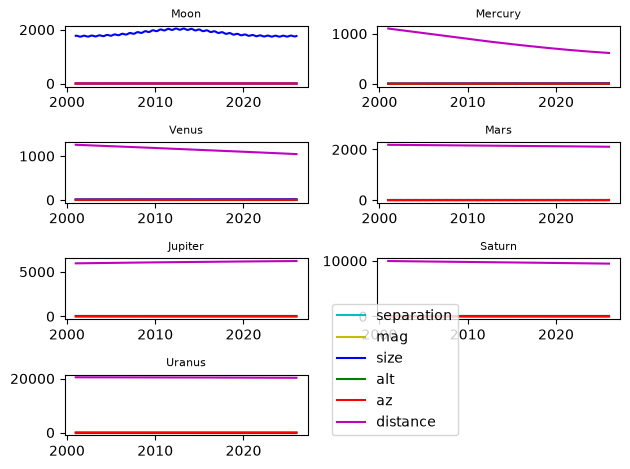

In [105]:
import matplotlib.pylab as plt
import numpy as np

xAxis = np.linspace(2001, 2026, int(iterations)) # TODO: NO FORÇAR EL RANG
planetsArray = {}

for j, planet in enumerate(planets):
    values = {'separation': {}, 'mag': {}, 'size': {}, 'alt': {}, 'az': {}, 'distance': {}}

    for i in range(len(measurings[planet.name])):
        values["separation"][i] = list(measurings[planet.name].values())[i]["separation"]
        values["mag"][i] = list(measurings[planet.name].values())[i]["mag"]
        values["size"][i] = list(measurings[planet.name].values())[i]["size"]
        values["alt"][i] = list(measurings[planet.name].values())[i]["alt"]
        values["az"][i] = list(measurings[planet.name].values())[i]["az"]
        values["distance"][i] = list(measurings[planet.name].values())[i]["earth_distance"]

    # pretty(values)

    planetsArray[planet.name] = values

    ax = plt.subplot(4, 2, j+1)
    
    ax.plot(xAxis, values["separation"].values(), 'c', label="separation")
    ax.plot(xAxis, values["mag"].values(), 'y', label="mag")
    ax.plot(xAxis, values["size"].values(), 'b', label="size")
    ax.plot(xAxis, values["alt"].values(), 'g', label="alt")
    ax.plot(xAxis, values["az"].values(), 'r', label="az")
    ax.plot(xAxis, values["distance"].values(), 'm', label="distance")
    ax.set_title(planet.name, fontsize=8)


plt.tight_layout()
plt.legend(loc=(1.1,0))
plt.show()

## Get planets within viewing scope

Good tools to check if calculations are correct: https://stellarium-web.org/, https://heavens-above.com/

In [106]:
# Using azalts

viewing_angle = ephem.degrees("20:00:00.0") # Minimum azimuth to consider a planet visible (higher az = higher in the sky)

visiblePlanets = {}

for j in range(len(measurings["Moon"])):
    visiblePlanetsAtThisTime = {}

    for i, planet in enumerate(planets):
        thisPlanet = list(measurings[planet.name].values())[j]

        if(thisPlanet['alt'] > viewing_angle):
            time = list(measurings[planet.name].keys())[j]
            # print('%s is visible from %s at %s with %s degrees separation' % (planet.name, observer.name, time, separation))
            visiblePlanetsAtThisTime[planet.name] = {
                'separation': thisPlanet['separation'], 
                'mag': thisPlanet['mag'],
                'size': thisPlanet['size'], 
                'alt': thisPlanet['alt'],
                'az': thisPlanet['az'], 
                'distance': thisPlanet['earth_distance'], 
                'time': time.split(" ")[1]
            }
    if(visiblePlanetsAtThisTime):
     visiblePlanets[time] = {**visiblePlanetsAtThisTime}

pretty(visiblePlanets)


2026/6/1 06:00:00
	Mars
		separation
			41:04:23.3
		mag
			1.26
		size
			4.28660774230957
		alt
			34:48:36.4
		az
			102:23:19.5
		distance
			2183.544874191284
		time
			06:00:00
	Saturn
		separation
			39:39:47.2
		mag
			0.87
		size
			16.624032974243164
		alt
			42:46:54.9
		az
			136:44:20.3
		distance
			9961.481094360352
		time
			06:00:00
	Uranus
		separation
			52:46:29.6
		mag
			5.81
		size
			3.4439990520477295
		alt
			22:04:12.6
		az
			81:41:38.2
		distance
			20464.872360229492
		time
			06:00:00
2026/6/1 10:00:00
	Mercury
		separation
			71:44:35.0
		mag
			-0.52
		size
			6.16170072555542
		alt
			47:46:24.6
		az
			96:33:49.5
		distance
			1093.8538312911987
		time
			10:00:00
	Venus
		separation
			84:39:42.3
		mag
			-3.9
		size
			13.50006103515625
		alt
			33:53:47.8
		az
			85:54:18.3
		distance
			1253.3276081085205
		time
			10:00:00
	Mars
		separation
			41:07:11.9
		mag
			1.26
		size
			4.287365913391113
		alt
			62:35:52.3
		az
			188:56:16.4
		distance

In [98]:
sel = "Moon"
sel = measurings[sel]
monitor = 'mag'
vals = []
for i in range(len(measurings)):
    vals.append(list(sel.values())[i][monitor])

print(min(vals), max(vals))


-7.78 -7.75


# Fent servir OSC

In [99]:
!pip3 install python-osc


[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


In [100]:
from pythonosc import udp_client
import time as t
from datetime import datetime
import math

client = udp_client.SimpleUDPClient("127.0.0.1", 5050, timeout=10)

In [108]:
duration_s = 60 * 2.5
data_points = len(visiblePlanets)
print(data_points)
timeInterval = duration_s/data_points
print(timeInterval)

134
1.1194029850746268


In [109]:
client.send_message("/timeInterval", timeInterval)

planetsMinMax = {
    'Moon': {
        'separation': {
            'min': 10000000,
            'max': -10000000
        },
        'mag': {
            'min': 10000000,
            'max': -10000000
        },
        'size': {
            'min': 10000000,
            'max': -10000000
        },
        'alt': {
            'min': 10000000,
            'max': -10000000
        },
        'az':{
            'min': 10000000,
            'max': -10000000
        },
        'distance': {
            'min': 10000000,
            'max': -10000000
        }
    },
    'Mercury': {
        'separation': {
            'min': 10000000,
            'max': -10000000
        },
        'mag': {
            'min': 10000000,
            'max': -10000000
        },
        'size': {
            'min': 10000000,
            'max': -10000000
        },
        'alt': {
            'min': 10000000,
            'max': -10000000
        },
        'az':{
            'min': 10000000,
            'max': -10000000
        },
        'distance': {
            'min': 10000000,
            'max': -10000000
        }
    },
    'Venus': {
        'separation': {
            'min': 10000000,
            'max': -10000000
        },
        'mag': {
            'min': 10000000,
            'max': -10000000
        },
        'size': {
            'min': 10000000,
            'max': -10000000
        },
        'alt': {
            'min': 10000000,
            'max': -10000000
        },
        'az':{
            'min': 10000000,
            'max': -10000000
        },
        'distance': {
            'min': 10000000,
            'max': -10000000
        }
    },
    'Mars': {
        'separation': {
            'min': 10000000,
            'max': -10000000
        },
        'mag': {
            'min': 10000000,
            'max': -10000000
        },
        'size': {
            'min': 10000000,
            'max': -10000000
        },
        'alt': {
            'min': 10000000,
            'max': -10000000
        },
        'az':{
            'min': 10000000,
            'max': -10000000
        },
        'distance': {
            'min': 10000000,
            'max': -10000000
        }
    },
    'Jupiter': {
        'separation': {
            'min': 10000000,
            'max': -10000000
        },
        'mag': {
            'min': 10000000,
            'max': -10000000
        },
        'size': {
            'min': 10000000,
            'max': -10000000
        },
        'alt': {
            'min': 10000000,
            'max': -10000000
        },
        'az':{
            'min': 10000000,
            'max': -10000000
        },
        'distance': {
            'min': 10000000,
            'max': -10000000
        }
    },
    'Saturn': {
        'separation': {
            'min': 10000000,
            'max': -10000000
        },
        'mag': {
            'min': 10000000,
            'max': -10000000
        },
        'size': {
            'min': 10000000,
            'max': -10000000
        },
        'alt': {
            'min': 10000000,
            'max': -10000000
        },
        'az':{
            'min': 10000000,
            'max': -10000000
        },
        'distance': {
            'min': 10000000,
            'max': -10000000
        }
    },
    'Uranus': {
        'separation': {
            'min': 10000000,
            'max': -10000000
        },
        'mag': {
            'min': 10000000,
            'max': -10000000
        },
        'size': {
            'min': 10000000,
            'max': -10000000
        },
        'alt': {
            'min': 10000000,
            'max': -10000000
        },
        'az':{
            'min': 10000000,
            'max': -10000000
        },
        'distance': {
            'min': 10000000,
            'max': -10000000
        }
    }
}

for i, date in enumerate(visiblePlanets):
    planetsVisibleNow = visiblePlanets[date]

    for j, planet in enumerate(planetsVisibleNow):
        data = planetsVisibleNow[planet]
        this_separation = data['separation']
        this_mag = data['mag']
        this_size = data['size']
        this_alt = data['alt']
        this_az = data['az']
        this_distance = data['distance']

        planetsMinMax[planet]['separation']['min'] = this_separation if this_separation < planetsMinMax[planet]['separation']['min'] else planetsMinMax[planet]['separation']['min']
        planetsMinMax[planet]['separation']['max'] = this_separation if this_separation > planetsMinMax[planet]['separation']['max'] else planetsMinMax[planet]['separation']['max']
        planetsMinMax[planet]['mag']['min'] = this_mag if this_mag < planetsMinMax[planet]['mag']['min'] else planetsMinMax[planet]['mag']['min']
        planetsMinMax[planet]['mag']['max'] = this_mag if this_mag > planetsMinMax[planet]['mag']['max'] else planetsMinMax[planet]['mag']['max']
        planetsMinMax[planet]['size']['min'] = this_size if this_size < planetsMinMax[planet]['size']['min'] else planetsMinMax[planet]['size']['min']
        planetsMinMax[planet]['size']['max'] = this_size if this_size > planetsMinMax[planet]['size']['max'] else planetsMinMax[planet]['size']['max']
        planetsMinMax[planet]['alt']['min'] = this_alt if this_alt < planetsMinMax[planet]['alt']['min'] else planetsMinMax[planet]['alt']['min']
        planetsMinMax[planet]['alt']['max'] = this_alt if this_alt > planetsMinMax[planet]['alt']['max'] else planetsMinMax[planet]['alt']['max']
        planetsMinMax[planet]['az']['min'] = this_az if this_az < planetsMinMax[planet]['az']['min'] else planetsMinMax[planet]['az']['min']
        planetsMinMax[planet]['az']['max'] = this_az if this_az > planetsMinMax[planet]['az']['max'] else planetsMinMax[planet]['az']['max']
        planetsMinMax[planet]['distance']['min'] = this_distance if this_distance < planetsMinMax[planet]['distance']['min'] else planetsMinMax[planet]['distance']['min']
        planetsMinMax[planet]['distance']['max'] = this_distance if this_distance > planetsMinMax[planet]['distance']['max'] else planetsMinMax[planet]['distance']['max']

print(planetsMinMax)

for planet in planetsMinMax:
    for _, measure in enumerate(planetsMinMax[planet]):
        message = (
            "/planetInfo"+" /"+planet+" /"+measure, [
                planetsMinMax[planet][measure]['min'], 
                planetsMinMax[planet][measure]['max']
            ]
        )
        print(message)
        client.send_message(*message)
        t.sleep(0.5)
        

{'Moon': {'separation': {'min': 0.5811407037214036, 'max': 2.5857383051490705}, 'mag': {'min': -11.94, 'max': -4.57}, 'size': {'min': 1777.04248046875, 'max': 2042.1597900390625}, 'alt': {'min': 0.3496241569519043, 'max': 1.2725036144256592}, 'az': {'min': 1.3700209856033325, 'max': 5.008976459503174}, 'distance': {'min': 2.3495841305702925, 'max': 2.7001164853572845}}, 'Mercury': {'separation': {'min': 1.252152367203142, 'max': 1.6678415734985546}, 'mag': {'min': -0.52, 'max': 1.97}, 'size': {'min': 6.16170072555542, 'max': 10.939266204833984}, 'alt': {'min': 0.4276379346847534, 'max': 1.2647210359573364}, 'az': {'min': 1.633591651916504, 'max': 4.873466491699219}, 'distance': {'min': 616.1291003227234, 'max': 1093.8538312911987}}, 'Venus': {'separation': {'min': 1.4776264654333389, 'max': 1.9481071763522495}, 'mag': {'min': -3.99, 'max': -3.9}, 'size': {'min': 13.50006103515625, 'max': 16.193315505981445}, 'alt': {'min': 0.42613109946250916, 'max': 1.2635726928710938}, 'az': {'min': 

In [110]:
for i, date in enumerate(visiblePlanets):
        planetsVisibleNow = visiblePlanets[date]

        outMessages = []

        for i, planet in enumerate(planetsVisibleNow):
            planetInfo = planetsVisibleNow[planet]
            print(planet, planetInfo)

            message = (
                "/"+planet, [
                    planetInfo['separation'],
                    planetInfo['mag'],
                    planetInfo['size'],
                    planetInfo['alt'],
                    planetInfo['az'],
                    planetInfo['distance'],
                    planetInfo['time']
                ]
            )
            outMessages.append(message)

        # print(notes_on, notes_off)
        for message in outMessages:
            # print('Sending message', message)
            client.send_message(*message)
        t.sleep(timeInterval)

client.send_message("/globalMute", 0)



Mars {'separation': 0.7168614781255551, 'mag': 1.26, 'size': 4.28660774230957, 'alt': 0.6075510382652283, 'az': 1.7870208024978638, 'distance': 2183.544874191284, 'time': '06:00:00'}
Saturn {'separation': 0.6922520658059075, 'mag': 0.87, 'size': 16.624032974243164, 'alt': 0.746685266494751, 'az': 2.386545181274414, 'distance': 9961.481094360352, 'time': '06:00:00'}
Uranus {'separation': 0.9210955922886598, 'mag': 5.81, 'size': 3.4439990520477295, 'alt': 0.38519707322120667, 'az': 1.425828456878662, 'distance': 20464.872360229492, 'time': '06:00:00'}
Mercury {'separation': 1.252152367203142, 'mag': -0.52, 'size': 6.16170072555542, 'alt': 0.8338047862052917, 'az': 1.6853551864624023, 'distance': 1093.8538312911987, 'time': '10:00:00'}
Venus {'separation': 1.4776264654333389, 'mag': -3.9, 'size': 13.50006103515625, 'alt': 0.5916076898574829, 'az': 1.4993263483047485, 'distance': 1253.3276081085205, 'time': '10:00:00'}
Mars {'separation': 0.7176786997090887, 'mag': 1.26, 'size': 4.28736591